# Retail Sales & Profit Analysis & Prediction

## 1. Project Overview

This project focuses on analyzing retail sales data to identify key factors affecting sales performance and profitability across different regions, product categories, and customer segments.

The analysis was performed using Python, SQL, and Power BI, applying data cleaning, exploratory data analysis (EDA), feature engineering, and machine learning techniques on a dataset containing over 50,000 records.

The project identifies important business insights such as the impact of discount levels and shipping costs on profitability. Machine learning models were implemented for profit prediction and classification, with Random Forest providing the most reliable performance.

The final outcome supports data-driven business decisions related to pricing, profitability, and sales strategy.

### Business Objectives:

- Analyze sales and profit trends across regions and categories

- Identify factors negatively affecting profitability

- Understand the impact of discounts and shipping costs

- Predict profit using machine learning models

- Classify orders into profit or loss categories

- Support data-driven business decision-making

## 2.Data Understanding and Initial Exploration

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\mahen\OneDrive\Documents\Retail_Project\Data\SuperStoreOrders.csv")

In [4]:
df.shape

(51290, 21)

In [5]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [8]:
df[df["profit"]<0].shape

(12543, 21)

In [9]:
df["profit_label"]=df["profit"].apply(lambda x: 1 if x> 0 else 0)
df["profit_label"].value_counts()

profit_label
1    38079
0    13211
Name: count, dtype: int64

In [10]:
df.groupby("region")["profit"].sum().round()

region
Africa             88872.0
Canada             17817.0
Caribbean          34571.0
Central           311404.0
Central Asia      132480.0
EMEA               43898.0
East               91523.0
North             194598.0
North Asia        165578.0
Oceania           121667.0
South             140356.0
Southeast Asia     17852.0
West              108418.0
Name: profit, dtype: float64

In [11]:
df.groupby("region")["order_id"].count()

region
Africa             4587
Canada              384
Caribbean          1690
Central           11117
Central Asia       2048
EMEA               5029
East               2848
North              4785
North Asia         2338
Oceania            3487
South              6645
Southeast Asia     3129
West               3203
Name: order_id, dtype: int64

In [12]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
profit_label      0
dtype: int64

## 3.Data Cleaning and Feature Engineering

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"],format="mixed",dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"],format="mixed",dayfirst=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

In [15]:
df["order_date"].isnull().sum()
df["ship_date"].isnull().sum()

np.int64(0)

In [16]:
df["shipping_days"]=(df["ship_date"]-df["order_date"]).dt.days

In [17]:
df[["order_date","ship_date","shipping_days"]].head(10)

,order_date,ship_date,shipping_days
0,2011-01-01,2011-01-06,5
1,2011-01-01,2011-01-08,7
2,2011-01-01,2011-01-05,4
3,2011-01-01,2011-01-05,4
4,2011-01-01,2011-01-08,7
5,2011-01-01,2011-01-08,7
6,2011-01-02,2011-01-06,4
7,2011-01-03,2011-01-03,0
8,2011-01-03,2011-01-09,6
9,2011-01-03,2011-01-07,4


In [18]:
df["shipping_days"].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

In [19]:
df[df["shipping_days"]<0]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_label,shipping_days


In [20]:
df["order_year"]=df["order_date"].dt.year

In [21]:
df[["order_date","order_year"]].head(20)

,order_date,order_year
0,2011-01-01,2011
1,2011-01-01,2011
2,2011-01-01,2011
3,2011-01-01,2011
4,2011-01-01,2011
5,2011-01-01,2011
6,2011-01-02,2011
7,2011-01-03,2011
8,2011-01-03,2011
9,2011-01-03,2011


In [22]:
df["order_month"]=df["order_date"].dt.month

In [23]:
df[["order_date","order_month"]].head(20)

,order_date,order_month
0,2011-01-01,1
1,2011-01-01,1
2,2011-01-01,1
3,2011-01-01,1
4,2011-01-01,1
5,2011-01-01,1
6,2011-01-02,1
7,2011-01-03,1
8,2011-01-03,1
9,2011-01-03,1


In [24]:
df["order_day_name"]=df["order_date"].dt.day_name()

In [25]:
df[["order_date","order_day_name"]].head(20)

,order_date,order_day_name
0,2011-01-01,Saturday
1,2011-01-01,Saturday
2,2011-01-01,Saturday
3,2011-01-01,Saturday
4,2011-01-01,Saturday
5,2011-01-01,Saturday
6,2011-01-02,Sunday
7,2011-01-03,Monday
8,2011-01-03,Monday
9,2011-01-03,Monday


In [26]:
df[["order_date","order_year","order_month","order_day_name","shipping_days"]].head(20)

,order_date,order_year,order_month,order_day_name,shipping_days
0,2011-01-01,2011,1,Saturday,5
1,2011-01-01,2011,1,Saturday,7
2,2011-01-01,2011,1,Saturday,4
3,2011-01-01,2011,1,Saturday,4
4,2011-01-01,2011,1,Saturday,7
5,2011-01-01,2011,1,Saturday,7
6,2011-01-02,2011,1,Sunday,4
7,2011-01-03,2011,1,Monday,0
8,2011-01-03,2011,1,Monday,6
9,2011-01-03,2011,1,Monday,4


In [27]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'profit_label', 'shipping_days', 'order_year', 'order_month',
       'order_day_name'],
      dtype='object')

In [28]:
df["shipping_days"].mean()

np.float64(3.96937024761162)

In [29]:
df.groupby("region")["shipping_days"].mean().sort_values(ascending=False)

region
North             4.033856
Central           4.033642
Southeast Asia    4.031640
Central Asia      4.005371
Caribbean         3.973964
South             3.944018
EMEA              3.933386
Oceania           3.932894
West              3.930066
Africa            3.910399
East              3.909761
North Asia        3.907613
Canada            3.677083
Name: shipping_days, dtype: float64

In [30]:
df["order_day_name"].value_counts()

order_day_name
Friday       9348
Tuesday      9307
Monday       9177
Wednesday    9017
Thursday     8871
Saturday     4580
Sunday        990
Name: count, dtype: int64

## 4.Exploratory Data Analysis

In this section, exploratory data analysis is performed to understand sales and profit patterns across different categories, regions, and time periods. This analysis helps identify important trends and factors affecting business performance.

In [31]:
sales_by_category=df.groupby("category")["sales"].sum().sort_values(ascending=False)
sales_by_category

category
Office Supplies    4081206645552763381231353652628147617186140149...
Technology         3149121931956922316638283924452743881747562,17...
Furniture          114667211854159691,64838493242,574155262,47998...
Name: sales, dtype: object

In [32]:
df["sales"].dtype

dtype('O')

In [33]:
df["sales"]=pd.to_numeric(df["sales"],errors="coerce")

In [34]:
df["sales"].dtype

dtype('float64')

In [35]:
sales_by_category=df.groupby("category")["sales"].sum().sort_values(ascending=False)
sales_by_category

category
Office Supplies    2790258.0
Technology         2638265.0
Furniture          2406605.0
Name: sales, dtype: float64

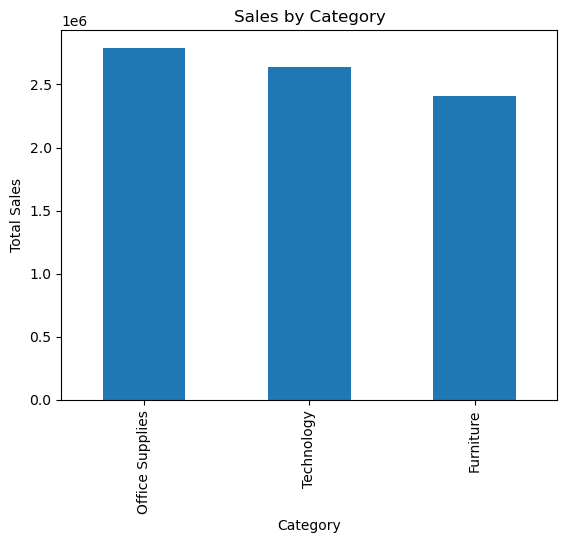

In [36]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Insight



- Office Supplies generates the highest total sales among all categories, indicating strong demand for office-related products.

- Furniture records the lowest total sales, suggesting comparatively lower demand in this category.

In [37]:
sales_by_region=df.groupby("region")["sales"].sum().sort_values(ascending=False)
sales_by_region

region
Central           1806638.0
South             1031101.0
North              790546.0
Oceania            625382.0
EMEA               575562.0
Africa             538115.0
Southeast Asia     532172.0
North Asia         453686.0
West               424173.0
Central Asia       389506.0
East               366492.0
Caribbean          251441.0
Canada              50314.0
Name: sales, dtype: float64

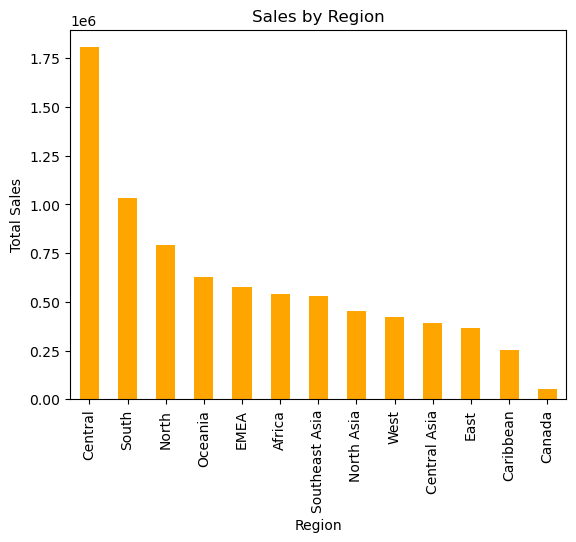

In [38]:
sales_by_region.plot(kind="bar",color="orange")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

### Insight



- The Central region generates the highest total sales, indicating strong business activity in this region.

- Canada contributes the lowest sales volume, suggesting a smaller market presence.

In [39]:
profit_by_category=df.groupby("category")["profit"].sum().sort_values(ascending=False).round()
profit_by_category

category
Technology         663779.0
Office Supplies    518474.0
Furniture          286782.0
Name: profit, dtype: float64

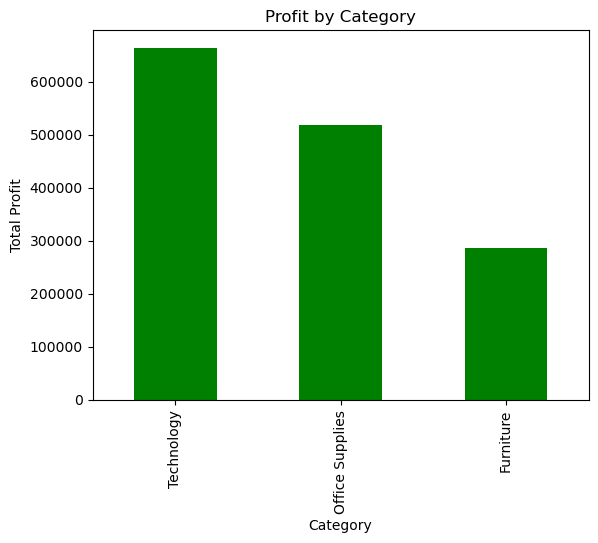

In [40]:
profit_by_category.plot(kind="bar",color="green")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

### Insight



- Technology category generates the highest profit, making it the most profitable product category.

- Furniture generates comparatively lower profit despite significant sales, suggesting higher costs or discounts.

In [41]:
profit_by_region=df.groupby("region")["profit"].sum().sort_values(ascending=False).round()
profit_by_region

region
Central           311404.0
North             194598.0
North Asia        165578.0
South             140356.0
Central Asia      132480.0
Oceania           121667.0
West              108418.0
East               91523.0
Africa             88872.0
EMEA               43898.0
Caribbean          34571.0
Southeast Asia     17852.0
Canada             17817.0
Name: profit, dtype: float64

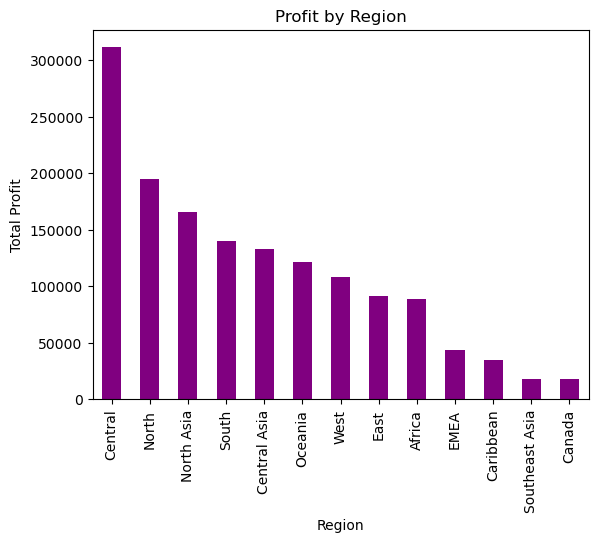

In [42]:
profit_by_region.plot(kind="bar",color="purple")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

### Insight



- The Central region produces the highest profit among all regions.

- Regions such as Canada and Southeast Asia generate comparatively lower profit.

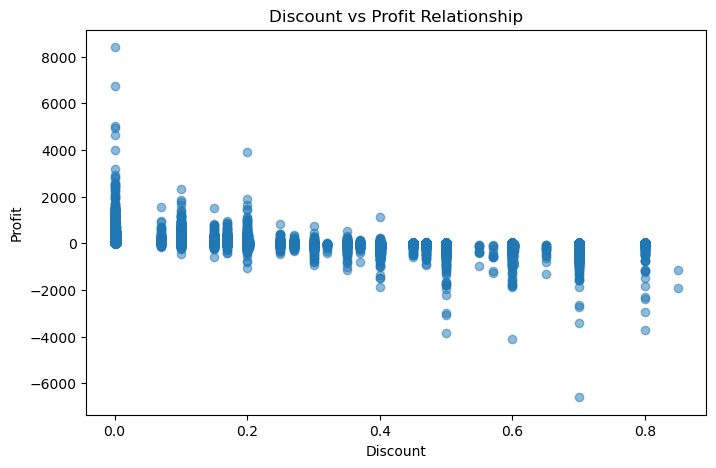

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df["discount"],df["profit"],alpha=0.5)

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()            

### Insight



- As discount increases, profit tends to decrease.

- High discount levels are often associated with negative profit, indicating excessive discounting impacts profitability.

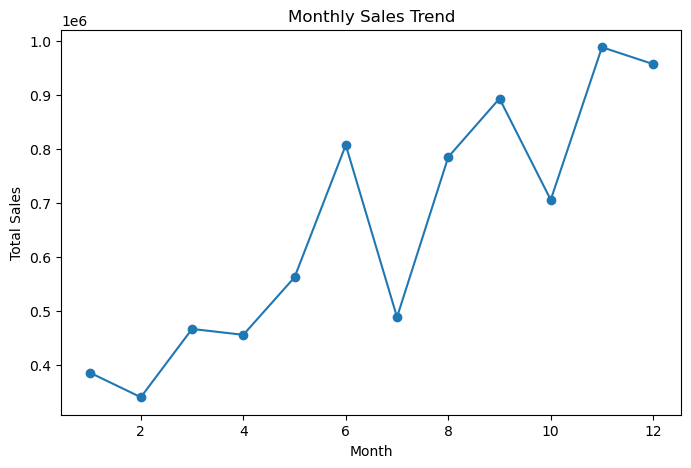

In [44]:
plt.figure(figsize=(8,5))
monthly_sales=df.groupby("order_month")["sales"].sum()
monthly_sales.plot(kind="line",marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

### Insight



- Sales fluctuate across months but generally show higher values in later months of the year.

- This trend suggests possible seasonal demand patterns in retail sales.

### Correlation Analysis

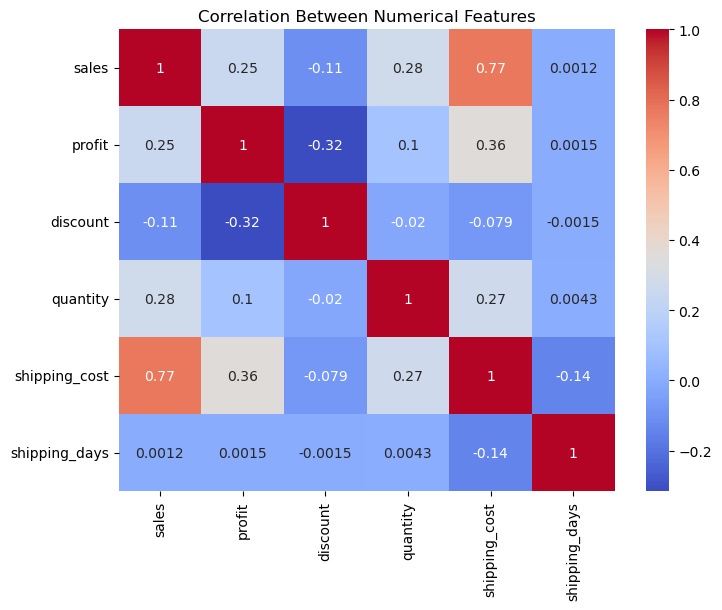

In [45]:
import seaborn as sns

corr=df[["sales","profit","discount","quantity","shipping_cost","shipping_days"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Between Numerical Features")
plt.show()

### Insight



- Sales and shipping cost show a strong positive correlation, indicating larger orders often involve higher shipping expenses.

- Discount shows a negative relationship with profit, suggesting that higher discounts reduce profitability

### Top Profitable Products

In [46]:
top_products=df.groupby("product_name")["profit"].sum().sort_values(ascending=False).head(10).round()
top_products

product_name
Canon imageCLASS 2200 Advanced Copier                       25200.0
Cisco Smart Phone, Full Size                                17239.0
Motorola Smart Phone, Full Size                             17027.0
Hoover Stove, Red                                           11808.0
Sauder Classic Bookcase, Traditional                        10672.0
Harbour Creations Executive Leather Armchair, Adjustable    10427.0
Nokia Smart Phone, Full Size                                 9938.0
Cisco Smart Phone, with Caller ID                            9787.0
Nokia Smart Phone, with Caller ID                            9465.0
Belkin Router, USB                                           8955.0
Name: profit, dtype: float64

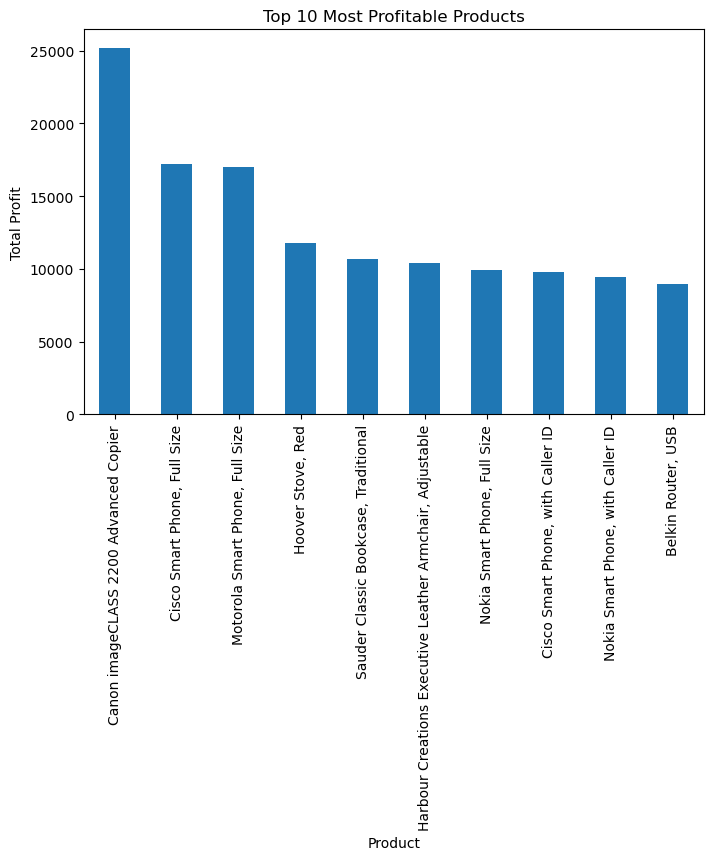

In [47]:
plt.figure(figsize=(8,5))
top_products.plot(kind="bar")

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Product")
plt.ylabel("Total Profit")

plt.show()

### Insight



- Several technology products appear among the most profitable items.

- Canon imageCLASS 2200 Advanced Copier generates the highest profit among all products.

### Top Loss-Making Products

In [48]:
loss_products = df.groupby("product_name")["profit"].sum().sort_values().head(10).round()
loss_products

product_name
Cubify CubeX 3D Printer Double Head Print                  -8880.0
Lexmark MX611dhe Monochrome Laser Printer                  -4590.0
Motorola Smart Phone, Cordless                             -4447.0
Cubify CubeX 3D Printer Triple Head Print                  -3840.0
Bevis Round Table, Adjustable Height                       -3650.0
Bevis Computer Table, Fully Assembled                      -3510.0
Rogers Lockers, Blue                                       -2893.0
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.0
Bevis Wood Table, with Bottom Storage                      -2783.0
Lesro Training Table, Rectangular                          -2581.0
Name: profit, dtype: float64

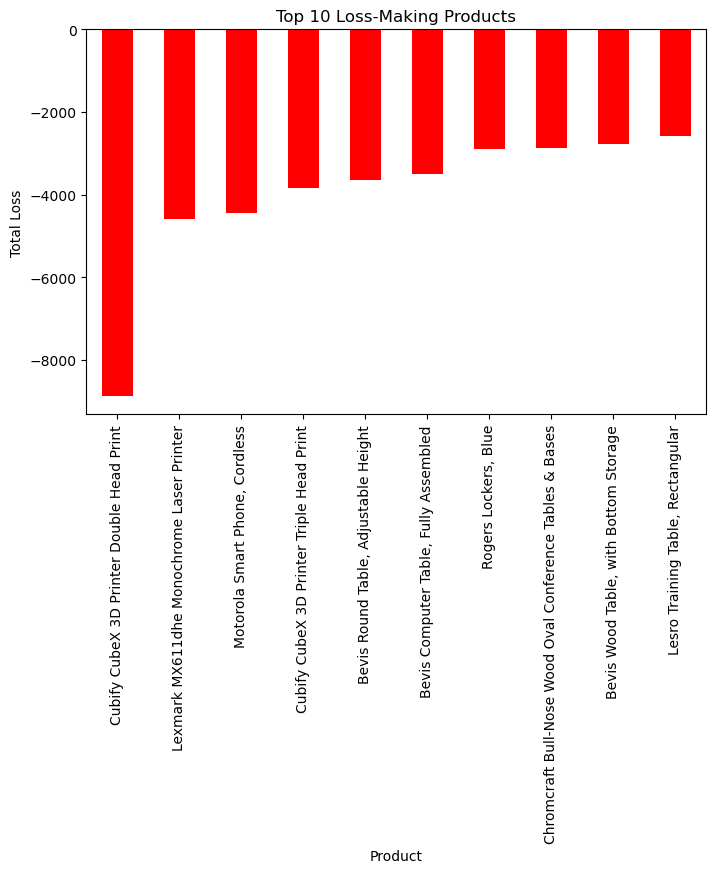

In [49]:
plt.figure(figsize=(8,5))
loss_products.plot(kind="bar", color="red")

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Product")
plt.ylabel("Total Loss")

plt.show()

### Insight



- Some products generate significant losses, indicating pricing or cost management issues.

- Products such as Cubify CubeX 3D Printer contribute to the largest losses.

### Profit by Customer Segment

In [50]:
segment_profit = df.groupby("segment")["profit"].sum().sort_values(ascending=False).round()
segment_profit

segment
Consumer       749240.0
Corporate      442786.0
Home Office    277009.0
Name: profit, dtype: float64

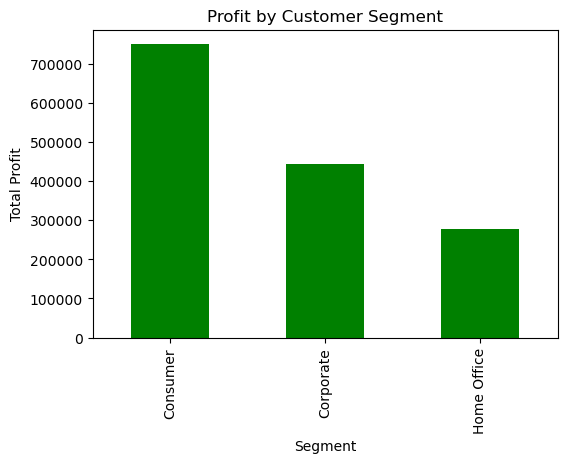

In [51]:
plt.figure(figsize=(6,4))
segment_profit.plot(kind="bar", color="green")

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")

plt.show()

### Insight



- The Consumer segment contributes the highest total profit.

- The Home Office segment generates comparatively lower profit.

### Profit Distribution

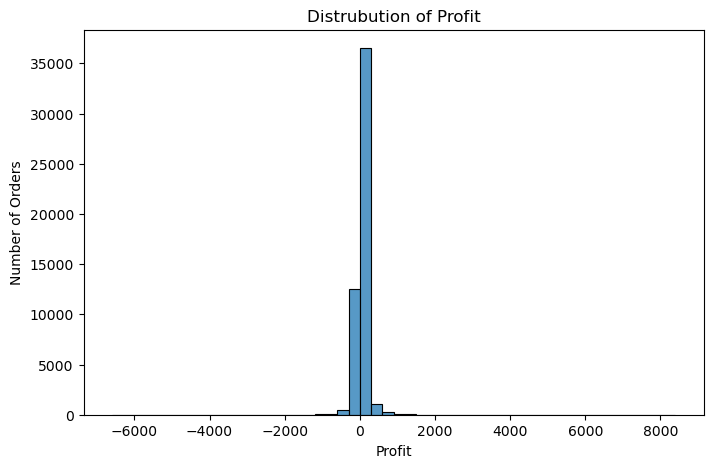

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["profit"],bins=50)

plt.title("Distrubution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")

plt.show()

### Insight



- Most transactions generate small profits around the center of the distribution.

- A smaller number of orders produce very high profits or large losses.

### Sales vs Profit Relationship

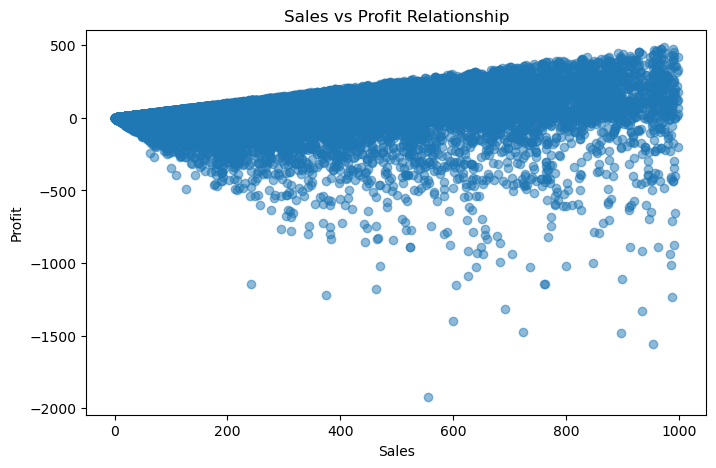

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(df["sales"], df["profit"], alpha=0.5)

plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

### Insight



- Higher sales generally lead to higher profit.

- However, some high-sales transactions still result in losses due to discounts or costs.

### Quantity vs Profit

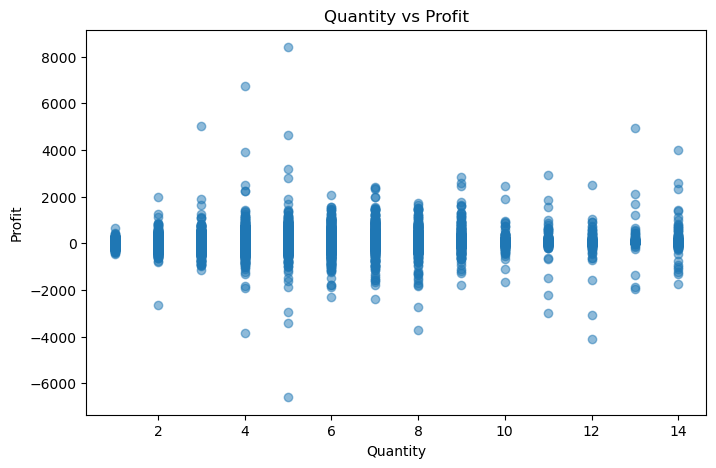

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(df["quantity"], df["profit"], alpha=0.5)

plt.title("Quantity vs Profit")
plt.xlabel("Quantity")
plt.ylabel("Profit")

plt.show()

### Insight



- Increasing quantity does not always guarantee higher profit.

- Profitability depends on pricing, discounts, and product margins.

### Shipping Cost vs Profit

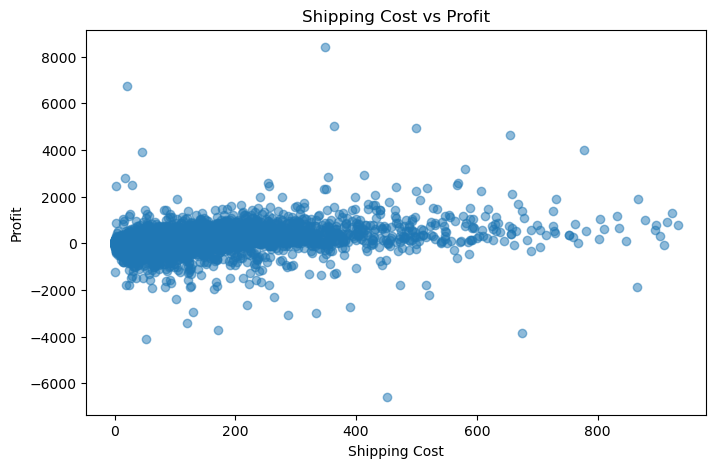

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(df["shipping_cost"], df["profit"], alpha=0.5)

plt.title("Shipping Cost vs Profit")
plt.xlabel("Shipping Cost")
plt.ylabel("Profit")

plt.show()

### Insight



- Higher shipping costs can reduce overall profitability.

- Efficient logistics management is important for maintaining profit margins

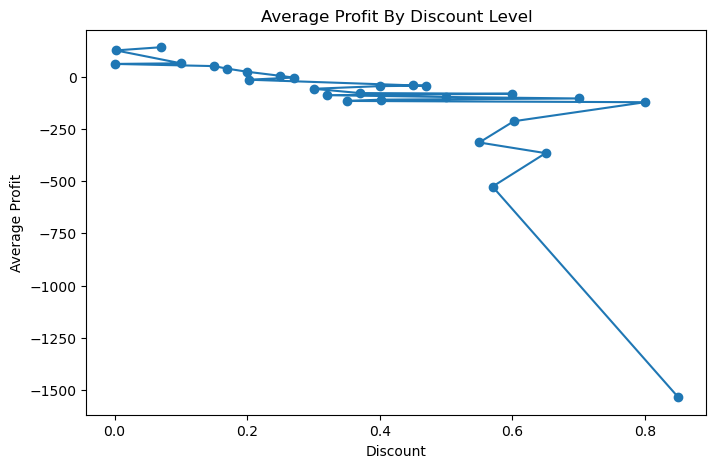

In [56]:
discount_profit=df.groupby("discount")["profit"].mean().sort_values()

plt.figure(figsize=(8,5))
discount_profit.plot(kind="line",marker="o")

plt.title("Average Profit By Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

### Insight



- Average profit decreases as discount levels increase.

- Discounts above 40% lead to negative average profit, indicating unsustainable pricing strategies.

In [57]:
df["profit_margin"] = df["profit"] / df["sales"]
df=df[df["sales"]!=0]

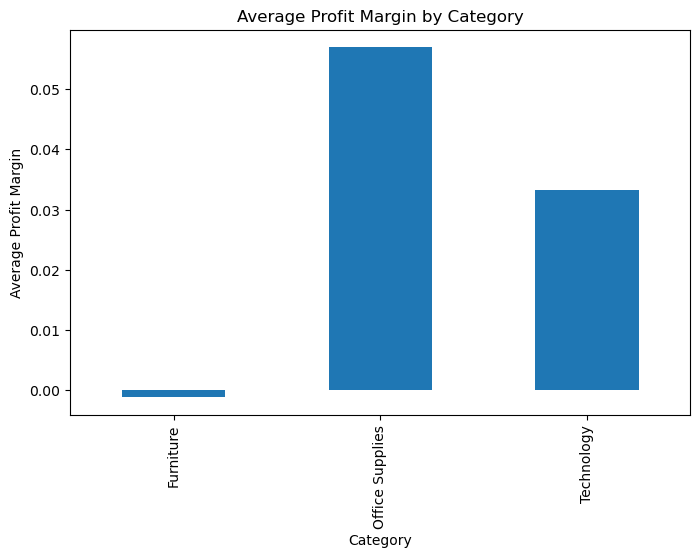

In [58]:
margin_category = df.groupby("category")["profit_margin"].mean()

plt.figure(figsize=(8,5))
margin_category.plot(kind="bar")

plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit Margin")

plt.show()

### Insight



- Office Supplies shows the highest average profit margin among all categories.

- Furniture records the lowest profit margin, indicating weaker profitability.

In [59]:
high_discount_loss=df[df["discount"]>0.4]["profit"].mean()

print(high_discount_loss)

-90.14510271264369


## 5.Machine Learning Preparation

In this section, the dataset is prepared for machine learning modeling. 
Relevant numerical variables that influence profitability are selected as input features. 
These include sales, quantity, discount, shipping cost, and shipping days.

The target variable for prediction is profit. 
The goal of the machine learning model is to learn the relationship between these features 
and predict the profit generated from each order.

In [60]:
features = df[
    [
        "sales",
        "quantity",
        "discount",
        "shipping_cost",
        "shipping_days"
    ]
]

target = df["profit"]

## 6.Machine Learning

In [61]:
df.isnull().sum()

order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_name        0
segment              0
state                0
country              0
market               0
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales             2630
quantity             0
discount             0
profit               0
shipping_cost        0
order_priority       0
year                 0
profit_label         0
shipping_days        0
order_year           0
order_month          0
order_day_name       0
profit_margin     2630
dtype: int64

In [62]:
df["sales"]=df["sales"].fillna(df["sales"].mean())
df["profit_margin"]=df["profit_margin"].fillna(df["profit_margin"].mean())

In [63]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
profit_label      0
shipping_days     0
order_year        0
order_month       0
order_day_name    0
profit_margin     0
dtype: int64

In [64]:
from sklearn.model_selection import train_test_split

x = df[["sales","quantity","discount","shipping_cost","shipping_days"]]
y = df["profit"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)

(41031, 5) (10258, 5)


### Regression Models

The objective of regression analysis is to predict profit values using machine learning models based on sales, discount, shipping cost, and other related features.

### Models Used

- LinearRegression
  
- DecisionTreeRegressor
  
- RandomForestRegressor

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [66]:
from sklearn.metrics import r2_score,mean_squared_error
import numpy as np

r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score:",r2)
print("RMSE:",rmse)

R2 Score: 0.27261163898271945
RMSE: 139.39431155123478


Linear Regression is used as a baseline model to predict profit.
Model performance is evaluated using R² score and RMSE.

In [67]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

In [68]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree R2:", r2_dt)
print("Decision Tree RMSE:", rmse_dt)

Decision Tree R2: -0.13890635829806697
Decision Tree RMSE: 174.4238572142421


In [69]:
print("Linear Regression R2:", r2)
print("Decision Tree R2:", r2_dt)

print("Linear Regression RMSE:", rmse)
print("Decision Tree RMSE:", rmse_dt)

Linear Regression R2: 0.27261163898271945
Decision Tree R2: -0.13890635829806697
Linear Regression RMSE: 139.39431155123478
Decision Tree RMSE: 174.4238572142421


In [70]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [71]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Improved Decision Tree R2:", r2_dt)
print("Improved Decision Tree RMSE:", rmse_dt)

Improved Decision Tree R2: 0.43727166220373226
Improved Decision Tree RMSE: 122.60587198205269


In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100 ,random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [73]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R2: 0.5106254939865329
Random Forest RMSE: 114.3358824442391


In [74]:
print("Linear Regression R2:", r2)
print("Decision Tree R2:", r2_dt)
print("Random Forest R2:", r2_rf)

print("Linear Regression RMSE:", rmse)
print("Decision Tree RMSE:", rmse_dt)
print("Random Forest RMSE:", rmse_rf)

Linear Regression R2: 0.27261163898271945
Decision Tree R2: 0.43727166220373226
Random Forest R2: 0.5106254939865329
Linear Regression RMSE: 139.39431155123478
Decision Tree RMSE: 122.60587198205269
Random Forest RMSE: 114.3358824442391


### Model Performance Comparision
| Model | R² Score | RMSE |
|---|---|---|
| Linear Regression | 0.2726 | 139.39 |
| Improved Decision Tree Regression | 0.4373 | 122.61 |
| Random Forest Regression | 0.5106 | 114.34 |

### Best Model Analysis

Random Forest Regression achieved the highest R² score and lowest RMSE among all regression models, making it the most reliable model for profit prediction.

### Regression Model Insights

- Linear Regression was used as a baseline model for profit prediction and provided moderate prediction performance.



- The initial Decision Tree Regression model showed poor generalization performance due to overfitting.



- After model improvement and parameter tuning, Improved Decision Tree Regression achieved significantly better prediction accuracy and reduced prediction error.



- Random Forest Regression achieved the best overall performance by effectively capturing complex non-linear relationships and reducing overfitting through ensemble learning.



- The regression analysis revealed that higher discount levels frequently reduced profit margins, while shipping costs also significantly influenced profitability.



- Random Forest Regression proved to be the most reliable model for business-oriented profit prediction.

### Feature Importance Analysis

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": x.columns,"Importance": rf.feature_importances_}).sort_values(
    by="Importance", ascending=False)

print("--- Feature Importance ---")
print(feature_importance)

--- Feature Importance ---
         Feature  Importance
3  shipping_cost    0.420901
2       discount    0.219284
0          sales    0.186047
1       quantity    0.094067
4  shipping_days    0.079702


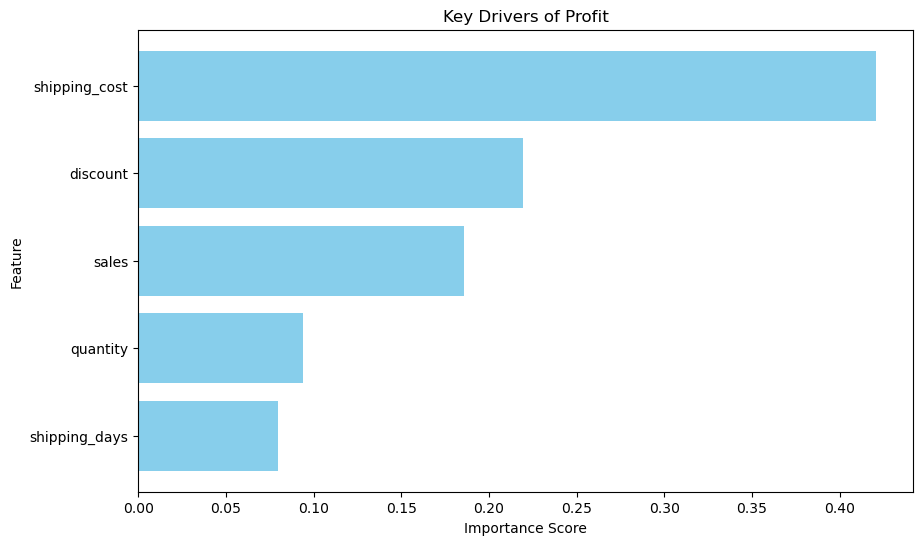

In [76]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Key Drivers of Profit")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Insights

- Shipping cost was identified as the most influential factor affecting profitability.

- Discount levels also had a major impact on profit, with higher discounts frequently reducing profit margins.

- Sales contributed positively to profit prediction, while quantity and shipping days showed comparatively lower influence.

- The feature importance analysis helped identify the key business drivers affecting retail profitability.

### Classification (Profit vs Loss)

The objective of classification analysis is to predict whether an order results in profit or loss based on sales, discount, shipping cost, and other related business features.

### Models Used

- Decision Tree Classification

- KNN Classification

- SVM Classification

In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(x_train, (y_train > 0).astype(int))

y_pred_clf = clf.predict(x_test)

y_test_label = (y_test > 0).astype(int)

print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test_label, y_pred_clf):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_label, y_pred_clf))

print("\nDetailed Classification Report:")
print(classification_report(y_test_label, y_pred_clf))


--- Model Evaluation ---
Accuracy Score: 91.44%

Confusion Matrix:
[[1982  653]
 [ 225 7398]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      2635
           1       0.92      0.97      0.94      7623

    accuracy                           0.91     10258
   macro avg       0.91      0.86      0.88     10258
weighted avg       0.91      0.91      0.91     10258



In [78]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, (y_train > 0).astype(int))

y_pred_knn = knn.predict(x_test)
y_test_label = (y_test > 0).astype(int)

print("\n--- KNN Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test_label, y_pred_knn):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_label, y_pred_knn))

print("\nDetailed Classification Report:")
print(classification_report(y_test_label, y_pred_knn))


--- KNN Evaluation ---
Accuracy Score: 76.25%

Confusion Matrix:
[[ 731 1904]
 [ 532 7091]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.28      0.38      2635
           1       0.79      0.93      0.85      7623

    accuracy                           0.76     10258
   macro avg       0.68      0.60      0.61     10258
weighted avg       0.73      0.76      0.73     10258



In [100]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

svm.fit(x_train_scaled, (y_train > 0).astype(int))

y_pred_svm = svm.predict(x_test_scaled)

y_test_label = (y_test > 0).astype(int)

print("\n--- SVM Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test_label, y_pred_svm):.2%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_label, y_pred_svm))

print("\nDetailed Classification Report:")
print(classification_report(y_test_label, y_pred_svm))


--- SVM Evaluation ---
Accuracy Score: 89.22%

Confusion Matrix:
[[2206  429]
 [ 677 6946]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      2635
           1       0.94      0.91      0.93      7623

    accuracy                           0.89     10258
   macro avg       0.85      0.87      0.86     10258
weighted avg       0.90      0.89      0.89     10258



### Model Accuracy Comparision
| Model | Accuracy |
|---|---|
| Decision Tree Classification | 91.44% |
| KNN Classification | 76.25% |
| SVM Classification | 89.22% |

### Best Model Analysis

Decision Tree Classification achieved the highest accuracy among all classification models by effectively capturing non-linear relationships within the dataset.

### Classification Model Insights

- Decision Tree Classification achieved the best overall classification performance with an accuracy of 91.44%.



- KNN Classification provided lower prediction accuracy and struggled to generalize effectively compared to other classification models.



- SVM Classification achieved strong performance by effectively separating profit and loss transactions using complex decision boundaries.



- Discount levels, shipping cost, sales, and quantity significantly influenced whether transactions resulted in profit or loss.



- Classification models successfully identified patterns associated with profitable and loss-making transactions.



- Decision Tree Classification proved to be the most reliable model for business-oriented classification analysis.

## Machine Learning Conclusion

Machine learning models were successfully implemented for both regression and classification tasks to analyze and predict retail business performance.

In regression analysis, Linear Regression provided baseline prediction performance, while Improved Decision Tree Regression achieved better accuracy after parameter tuning. Random Forest Regression delivered the best overall performance with the highest R² score and lowest RMSE, making it the most reliable model for profit prediction.

For classification analysis, Decision Tree Classification achieved the highest accuracy among all classification models, effectively identifying patterns associated with profit and loss transactions. SVM Classification also demonstrated strong performance, while KNN Classification showed comparatively lower accuracy.

The machine learning analysis revealed that shipping cost, discount, sales, and quantity significantly influenced profitability and transaction outcomes.

Overall, the machine learning models demonstrated how predictive analytics can support data-driven business decision-making related to pricing strategies, profitability optimization, and operational performance.

## 8.SQL Analysis
SQL queries were used to analyze sales performance, profitability trends, regional performance, and discount impact within the retail dataset.

In [5]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("retail.db")
df.to_sql("retail",conn,if_exists="replace",index=False)

51290

In [6]:
pd.read_sql("SELECT * FROM retail LIMIT 5;",conn)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


### Total Sales and Profit

In [108]:
query = """SELECT SUM(sales) AS total_sales,
SUM(profit) AS total_profit
FROM retail"""
pd.read_sql(query,conn)

,total_sales,total_profit
0,8.258614e+06,1.469036e+06


### Insight:
The business generated approximately 8.25 million in total sales but only around 1.46 million in profit, indicating a relatively low profit margin compared to total revenue.

### Profit by Region

In [109]:
query = """SELECT region,SUM(profit) AS total_profit
FROM retail
GROUP BY region
ORDER BY total_profit DESC"""
pd.read_sql(query,conn)

,region,total_profit
0,Central,311405.09164
1,North,194597.95252
2,North Asia,165578.42100
3,South,140355.76618
4,Central Asia,132480.18700
5,Oceania,121666.64200
6,West,108418.44890
7,East,91522.78000
8,Africa,88871.63100
9,EMEA,43897.97100


### Insight:
The Central region is the most profitable, contributing the highest total profit (~311K), while regions like Canada and Southeast Asia generate significantly lower profits.

### Category-wise Performance

In [110]:
query = """SELECT category,SUM(sales) AS total_sales,
SUM(profit) AS total_profit
FROM retail
GROUP BY category
ORDER BY total_profit DESC"""
pd.read_sql(query,conn)

,category,total_sales,total_profit
0,Technology,2.819092e+06,663778.73318
1,Office Supplies,2.876726e+06,518474.94430
2,Furniture,2.562796e+06,286782.25380


### Insight:
The Technology category generates the highest profit (~663K), followed by Office Supplies, while Furniture contributes the least profit.

### Discount impact on Profit

In [111]:
query = """SELECT discount,AVG(profit) AS avg_profit
FROM retail
GROUP BY discount
ORDER BY discount"""
pd.read_sql(query,conn)

,discount,avg_profit
0,0.000,61.039514
1,0.002,125.762649
2,0.070,140.990022
3,0.100,64.071216
4,0.150,50.602409
5,0.170,38.317107
6,0.200,23.552594
7,0.202,-14.518847
8,0.250,4.043371
9,0.270,-4.317213


### Insight:
At lower discount levels (0%–10%), average profit is high, but as discount increases beyond 20%, profit drops sharply and becomes negative, indicating losses.

### Monthly Sales Trend

In [112]:
query = """SELECT strftime('%m',order_date) AS month,
SUM(sales) AS total_sales FROM retail
GROUP BY month
ORDER BY month"""
pd.read_sql(query,conn)

,month,total_sales
0,01,4.102562e+05
1,02,3.573803e+05
2,03,4.901451e+05
3,04,4.774929e+05
4,05,5.942212e+05
5,06,8.485664e+05
6,07,5.123372e+05
7,08,8.308730e+05
8,09,9.416723e+05
9,10,7.449852e+05


### Insight:
Sales vary across months, with the highest sales observed in November and December, indicating strong year-end seasonal demand.

### High Profit Transactions (Subquery)

In [8]:
query = """SELECT * FROM retail
WHERE profit > (
    SELECT AVG(profit) FROM retail)"""
pd.read_sql(query, conn)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011
4,IN-2011-79397,3/1/2011,3/1/2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.1,110.412,125.32,Critical,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15015,MX-2014-122511,31-12-2014,5/1/2015,Standard Class,Rick Reed,Corporate,Santo Domingo,Dominican Republic,LATAM,Caribbean,...,Technology,Accessories,"Memorex Keyboard, Programmable",155,4,0.2,40.752,12.75,Medium,2014
15016,OD-2014-9490,31-12-2014,5/1/2015,Standard Class,Mitch Willingham,Corporate,Central Equatoria,South Sudan,Africa,Africa,...,Technology,Copiers,"Canon Wireless Fax, Digital",378,1,0.0,166.440,11.71,Medium,2014
15017,CA-2014-126221,31-12-2014,6/1/2015,Standard Class,Chuck Clark,Home Office,Indiana,United States,US,Central,...,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209,2,0.0,56.511,8.32,Medium,2014
15018,UP-2014-3330,31-12-2014,2/1/2015,First Class,Fred Wasserman,Corporate,Mykolayiv,Ukraine,EMEA,EMEA,...,Office Supplies,Fasteners,"OIC Thumb Tacks, Assorted Sizes",138,12,0.0,55.080,8.03,Medium,2014


### Insight:
This query identifies transactions where profit is higher than the average profit, highlighting above-average performing sales.

### High Performing Categories (HAVING)

In [9]:
query = """SELECT category, SUM(profit) AS total_profit FROM retail
GROUP BY category
HAVING total_profit > 50000"""
pd.read_sql(query, conn)

,category,total_profit
0,Furniture,286782.25380
1,Office Supplies,518473.83430
2,Technology,663778.73318


### Insight:
This query filters categories that generate significant profit, helping identify high-performing business segments.

### Profit vs Loss Classification (CASE WHEN)

In [11]:
query = """SELECT product_name,
        profit,CASE WHEN profit > 0 THEN 'Profit'
        ELSE 'Loss' END AS status
        FROM retail"""
pd.read_sql(query, conn)

,product_name,profit,status
0,"Tenex Lockers, Blue",106.1400,Profit
1,"Acme Trimmer, High Speed",36.0360,Profit
2,"Tenex Box, Single Width",29.6400,Profit
3,"Enermax Note Cards, Premium",-26.0550,Loss
4,"Eldon Light Bulb, Duo Pack",37.7700,Profit
...,...,...,...
51285,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",4.5188,Profit
51286,"Wilson Jones Hole Reinforcements, Clear",0.4200,Profit
51287,"Hon Color Coded Labels, 5000 Label Set",12.3600,Profit
51288,"Hon Legal Exhibit Labels, Alphabetical",0.5600,Profit


### Insight:
This query classifies transactions into profit and loss categories, making it easier to analyze business performance.

### Product Ranking by Profit (Window Function)

In [12]:
query = """SELECT product_name,
    SUM(profit) AS total_profit,
    RANK() OVER (ORDER BY SUM(profit) DESC) AS rank
FROM retail
GROUP BY product_name"""
pd.read_sql(query, conn)

,product_name,total_profit,rank
0,Canon imageCLASS 2200 Advanced Copier,25199.9280,1
1,"Cisco Smart Phone, Full Size",17238.5206,2
2,"Motorola Smart Phone, Full Size",17027.1130,3
3,"Hoover Stove, Red",11807.9690,4
4,"Sauder Classic Bookcase, Traditional",10672.0730,5
...,...,...,...
3783,"Bevis Round Table, Adjustable Height",-3649.8940,3784
3784,Cubify CubeX 3D Printer Triple Head Print,-3839.9904,3785
3785,"Motorola Smart Phone, Cordless",-4447.0380,3786
3786,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730,3787


### Insight:
This query ranks products based on total profit, helping identify the most and least profitable products.

### SQL Insights:
- The Central region is the most profitable among all regions.

- The Technology category generates the highest profit, while Furniture contributes comparatively less.

- Increasing discount levels negatively impact profitability; higher discounts consistently lead to net losses.

- Sales show distinct seasonal trends, with specific months generating significantly higher revenue.

- Profit distribution is skewed: a small group of products drives the majority of profit, while specific outliers result in consistent losses.

### SQL Conclusion:
The SQL analysis provided key insights into business performance by examining sales, profit, and trends. It identified the most profitable regions and product categories, highlighted the negative impact of high discounts on profitability, and revealed seasonal sales patterns. Advanced SQL techniques—including subqueries, the HAVING clause, CASE WHEN statements, and window functions—enabled deeper analysis and helped isolate high-performing versus loss-making areas. Overall, the analysis supports data-driven decision-making to optimize business performance.

## 9.Power BI Dashboard Analysis

![Dashboard](Dashboard.png)

### Power BI Dashboard File

- [Download Power BI Dashboard (.pbix)](https://drive.google.com/file/d/1h-JE61qfoOh6uRCHzvWKE95zJUzZIuxI/view?usp=drive_link)

### Purpose
This dashboard is created to analyze retail sales performance across regions, categories, products, and time. It helps identify key trends, profitability, and business insights.

### Key Metrics
- Total Sales: 12.64M  
- Total Profit: 1.47M  
- Profit Margin: 11.62%  
- Total Orders: 51K  

### Regional Sales Performance
The Central region generates the highest sales (approximately 2.8M), followed by South and North regions. This indicates strong performance in the Central region but also shows dependency on a single region for a large portion of revenue.

### Category Profitability
Office Supplies contributes the highest profit (around 31K), while Technology and Furniture generate significantly lower profits (around 10K each). This indicates that Office Supplies has better profit margins compared to other categories.

### Product Performance
The top 5 products, especially smartphones like Apple, Cisco, and Motorola, contribute a significant portion of total sales. This indicates that revenue is concentrated in a few products.

### Sales Trend Analysis
Sales fluctuate throughout the year, with peaks observed in February, June, and December, and lower sales in months like March and July. This indicates the presence of seasonal demand patterns.

### Order Volume Insight
The business processes approximately 51K orders, indicating a high-volume sales model with moderate average order value.

### Key Business Insights
- Sales are highly dependent on the Central region  
- Office Supplies is the most profitable category  
- Revenue is concentrated in a few top products  
- Sales show seasonal patterns throughout the year  

### Recommendations
- Improve performance in low-performing regions to reduce dependency  
- Focus on high-profit categories like Office Supplies  
- Diversify product portfolio to reduce reliance on a few products  
- Plan inventory and marketing strategies for peak months

## 10.Final Project Conclusion

This project successfully combined Python, SQL, Machine Learning, and Power BI to analyze retail sales performance, profitability trends, and business operations using a real-world retail dataset containing more than 50,000 records.

The analysis identified important business insights related to sales performance, regional profitability, discount impact, shipping cost influence, customer segments, and product-level performance. Exploratory Data Analysis revealed that excessive discounting and higher shipping costs negatively affected overall profitability, while Technology products and specific regions contributed significantly to total profit.

SQL analysis was used to perform business-focused querying and trend analysis, helping identify high-performing categories, profitable regions, seasonal sales patterns, and loss-making products. Advanced SQL operations such as subqueries, CASE WHEN statements, HAVING clauses, and window functions improved analytical depth and business understanding.

Machine learning models were implemented for both regression and classification tasks. In regression analysis, Random Forest Regression achieved the best overall performance with the highest R² score and lowest RMSE, making it the most reliable model for profit prediction. In classification analysis, Decision Tree Classification achieved the highest accuracy in identifying profit and loss transactions.

The Power BI dashboard provided interactive visual analysis of sales, profit, regional performance, category trends, product performance, and monthly sales patterns. The dashboard supported business decision-making through KPI tracking and dynamic filtering capabilities.

Overall, this project demonstrates practical skills in data cleaning, feature engineering, exploratory data analysis, SQL analysis, machine learning, and data visualization. The project highlights how data analytics and predictive modeling can support data-driven business decisions related to profitability optimization, pricing strategy, sales analysis, and operational performance.